**Project Title** : Customer Churn Analysis and
Prediction

**Introduction**:
This project analyzes telecom customer data and builds a machine learning model to predict customer churn. The objective is to identify customers who are likely to leave the service so companies can take preventive actions.

**Dataset Loading**

In [50]:
import pandas as pd
import numpy as np

In [51]:
df=pd.read_csv(r'/content/Telco_Customer_Churn_Dataset  (1).csv');

In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Dataset Description**:

The dataset contains telecom customer information including:

Gender

Tenure

Monthly Charges

Contract Type

Internet Service

Payment Method

Churn (Target Variable)

In [53]:
df.shape

(7043, 21)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**TASK** **1**: Data Preparation

In the data preprocessing phase, the dataset is cleaned and prepared for machine learning. Missing values are handled, unnecessary data is removed, and categorical variables are converted into numerical format using encoding techniques. This step ensures that the dataset is properly structured and suitable for training the machine learning model.

In [55]:
#handling missiong values

total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)
print(missing_data)

                  Total  Percent
customerID            0      0.0
gender                0      0.0
SeniorCitizen         0      0.0
Partner               0      0.0
Dependents            0      0.0
tenure                0      0.0
PhoneService          0      0.0
MultipleLines         0      0.0
InternetService       0      0.0
OnlineSecurity        0      0.0
OnlineBackup          0      0.0
DeviceProtection      0      0.0
TechSupport           0      0.0
StreamingTV           0      0.0
StreamingMovies       0      0.0
Contract              0      0.0
PaperlessBilling      0      0.0
PaymentMethod         0      0.0
MonthlyCharges        0      0.0
TotalCharges          0      0.0
Churn                 0      0.0


In [56]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [57]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [58]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [59]:
#Convert Catagorical value into Numerical Value using Label Encoder

from sklearn.preprocessing import LabelEncoder

In [60]:
#Encoding data

from sklearn.preprocessing import LabelEncoder
labelDict = {}
for feature in df:
    le = LabelEncoder()
    le.fit(df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    df[feature] = le.transform(df[feature])
    # Get labels
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] =labelValue
for key, value in labelDict.items():
    print(key, value)


label_customerID ['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-PEGZZ', '0

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   int64
 1   gender            7043 non-null   int64
 2   SeniorCitizen     7043 non-null   int64
 3   Partner           7043 non-null   int64
 4   Dependents        7043 non-null   int64
 5   tenure            7043 non-null   int64
 6   PhoneService      7043 non-null   int64
 7   MultipleLines     7043 non-null   int64
 8   InternetService   7043 non-null   int64
 9   OnlineSecurity    7043 non-null   int64
 10  OnlineBackup      7043 non-null   int64
 11  DeviceProtection  7043 non-null   int64
 12  TechSupport       7043 non-null   int64
 13  StreamingTV       7043 non-null   int64
 14  StreamingMovies   7043 non-null   int64
 15  Contract          7043 non-null   int64
 16  PaperlessBilling  7043 non-null   int64
 17  PaymentMethod     7043 non-null  

**Task** **2**: Split Data for Training and Testing

In this step, the dataset is divided into two parts: training data and testing data. Typically, 80% of the data is used for training the model, and 20% is used for testing. The training data helps the model learn patterns, while the testing data is used to evaluate how well the model performs on unseen data.

In [62]:
#Spliting the dataset into training and testing

x=df.drop('Churn', axis=1)

In [63]:
y=df['Churn']

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
#split into 80-20
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=4)

In [66]:
x_train.shape

(5634, 20)

In [67]:
x_train.value_counts()

,,,,,,,,,,,,,,,,,,,,count
customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,
7042,1,0,1,1,63,0,1,0,2,2,2,0,2,2,2,0,2,524,3196,1
0,0,0,1,1,9,1,0,0,0,2,0,2,2,0,1,1,3,640,4863,1
7021,0,0,1,1,1,1,0,2,1,1,1,1,1,1,0,0,3,30,1607,1
7020,1,1,0,0,21,1,0,1,0,0,2,0,2,2,0,1,0,1223,1663,1
7019,1,0,0,1,71,1,2,1,2,0,2,0,2,2,2,0,0,1409,5704,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,1,0,1,0,63,1,2,1,2,0,0,2,0,0,2,1,1,988,4478,1
5,0,0,0,1,9,1,0,0,0,0,0,2,2,2,0,1,1,703,4713,1
4,0,1,1,0,3,1,0,1,0,0,0,2,2,0,0,1,3,973,2324,1


In [68]:
x_test.shape

(1409, 20)

In [69]:
x_test.value_counts()

,,,,,,,,,,,,,,,,,,,,count
customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,
7037,0,0,0,0,4,1,0,2,1,1,1,1,1,1,0,0,0,48,6211,1
6974,1,0,0,0,66,1,2,1,2,2,2,2,2,2,1,1,0,1533,5706,1
6972,0,0,0,0,23,1,0,0,0,2,2,0,0,0,1,0,0,475,595,1
6971,0,0,0,0,1,1,0,1,0,2,0,0,0,0,0,1,1,793,5717,1
6964,0,0,1,0,25,1,2,0,0,2,0,0,0,0,0,0,2,441,672,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,0,0,1,1,1,0,1,0,2,0,0,0,0,0,0,0,0,154,2593,1
22,0,0,1,1,23,1,2,1,0,0,0,0,2,0,0,1,2,970,1411,1
18,1,1,0,0,45,1,0,0,2,0,2,0,0,2,1,0,1,590,2420,1


In [70]:
y_train.shape

(5634,)

In [71]:
y_test.shape

(1409,)

**Tasks** **3**: Feature Selection

Correlation analysis is used to identify the relationship between different features and the target variable (Churn). Features with higher correlation are more influential for prediction.

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
correlation = df.corr()

# Sort features by importance
print(correlation['Churn'].sort_values(ascending=False))

Churn               1.000000
PaperlessBilling    0.191825
MonthlyCharges      0.183523
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
TotalCharges        0.014479
PhoneService        0.011942
gender             -0.008612
customerID         -0.017447
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


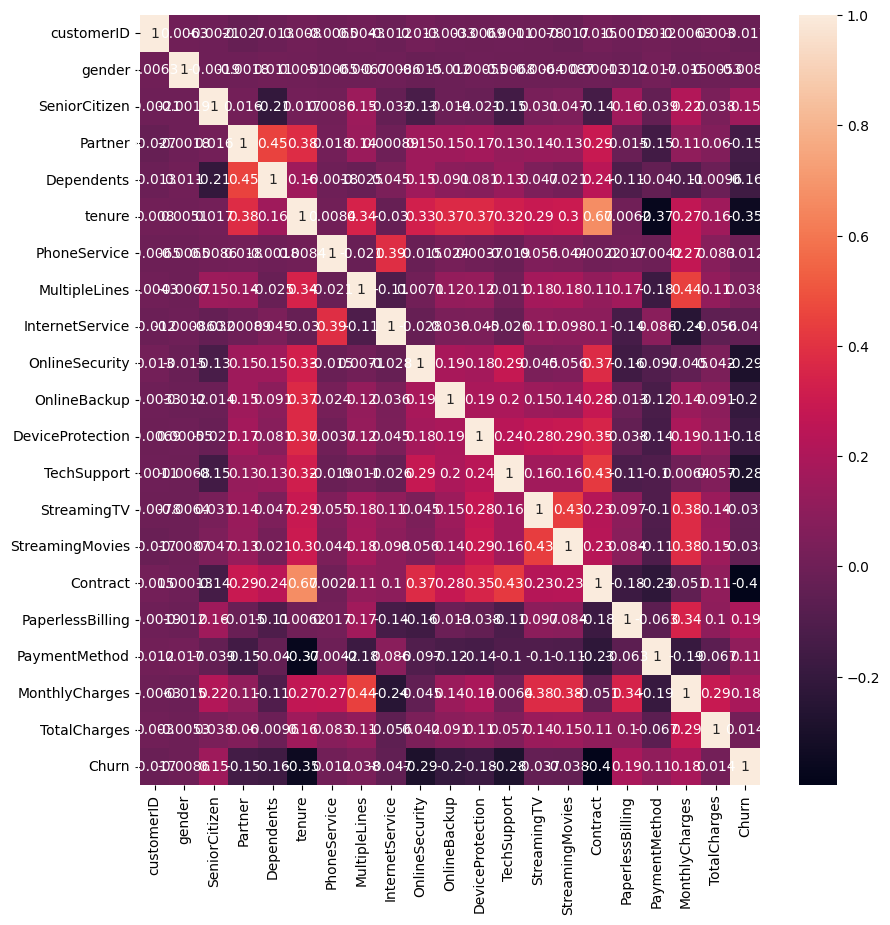

In [74]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True)
plt.show()

**Tasks** **4**: Model Selection -- **Random Forest**

A Random Forest classification model is selected because the problem is a binary classification task, where the target variable Churn has two possible values (Yes or No). Random Forest is a powerful ensemble algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. It works well for structured datasets and helps capture complex relationships between features.

**Tasks 5:** Model Training

In this phase, the Random Forest classification model is trained using the training dataset. The input features are used to learn patterns that influence customer churn, while the Churn column is used as the target variable. After training, the model can predict whether a customer is likely to churn or not.

In [75]:
#Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

In [76]:
#create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [77]:
# Train model
model.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [78]:
print("Model training completed")

Model training completed


**Task 6: Model Evaluation**

After training the model, its performance is evaluated using the test dataset. Evaluation metrics such as Accuracy, Precision, Recall, and F1-score are used to measure how well the model predicts customer churn. These metrics help determine the effectiveness and reliability of the machine learning model on unseen data.

In [79]:
# Prediction
y_pred = model.predict(x_test)

In [80]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7842441447835344


In [81]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6215277777777778


In [82]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.4786096256684492


In [83]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.540785498489426


**Conclusion**

The machine learning model successfully predicts telecom customer churn based on customer attributes. The Random Forest model demonstrates good performance in identifying customers likely to leave the service. This analysis can help telecom companies improve customer retention strategies.